In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.utils import image_dataset_from_directory
import pathlib
from tensorflow.keras.applications import MobileNetV2

In [2]:
data_path = pathlib.Path("./BIRDS 525 SPECIES-DataSet/")
train_path = pathlib.Path("./BIRDS 525 SPECIES-DataSet/train")
test_path = pathlib.Path("./BIRDS 525 SPECIES-DataSet/test")
valid_path = pathlib.Path("./BIRDS 525 SPECIES-DataSet/valid")

In [3]:
training_image_count = len(list(data_path.glob('train/*/*.jpg')))
test_image_count = len(list(data_path.glob('test/*/*.jpg')))
validation_image_count = len(list(data_path.glob('valid/*/*.jpg')))
total_count = training_image_count + test_image_count + validation_image_count

print(f"training_image_count: {training_image_count}")
print(f"test_image_count: {test_image_count}")
print(f"validation_image_count: {validation_image_count}")
print(f"total_count: {total_count}")

training_image_count: 84632
test_image_count: 2625
validation_image_count: 2625
total_count: 89882


In [4]:
batch_size = 32
img_height = 224
img_width = 224

train_ds = image_dataset_from_directory(
    train_path,
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    valid_path,
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_ds = image_dataset_from_directory(
    test_path,
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)

Found 84632 files belonging to 525 classes.
Found 2625 files belonging to 525 classes.
Found 2625 files belonging to 525 classes.
['ABBOTTS BABBLER', 'ABBOTTS BOOBY', 'ABYSSINIAN GROUND HORNBILL', 'AFRICAN CROWNED CRANE', 'AFRICAN EMERALD CUCKOO', 'AFRICAN FIREFINCH', 'AFRICAN OYSTER CATCHER', 'AFRICAN PIED HORNBILL', 'AFRICAN PYGMY GOOSE', 'ALBATROSS', 'ALBERTS TOWHEE', 'ALEXANDRINE PARAKEET', 'ALPINE CHOUGH', 'ALTAMIRA YELLOWTHROAT', 'AMERICAN AVOCET', 'AMERICAN BITTERN', 'AMERICAN COOT', 'AMERICAN DIPPER', 'AMERICAN FLAMINGO', 'AMERICAN GOLDFINCH', 'AMERICAN KESTREL', 'AMERICAN PIPIT', 'AMERICAN REDSTART', 'AMERICAN ROBIN', 'AMERICAN WIGEON', 'AMETHYST WOODSTAR', 'ANDEAN GOOSE', 'ANDEAN LAPWING', 'ANDEAN SISKIN', 'ANHINGA', 'ANIANIAU', 'ANNAS HUMMINGBIRD', 'ANTBIRD', 'ANTILLEAN EUPHONIA', 'APAPANE', 'APOSTLEBIRD', 'ARARIPE MANAKIN', 'ASHY STORM PETREL', 'ASHY THRUSHBIRD', 'ASIAN CRESTED IBIS', 'ASIAN DOLLARD BIRD', 'ASIAN GREEN BEE EATER', 'ASIAN OPENBILL STORK', 'AUCKLAND SHAQ', 'A

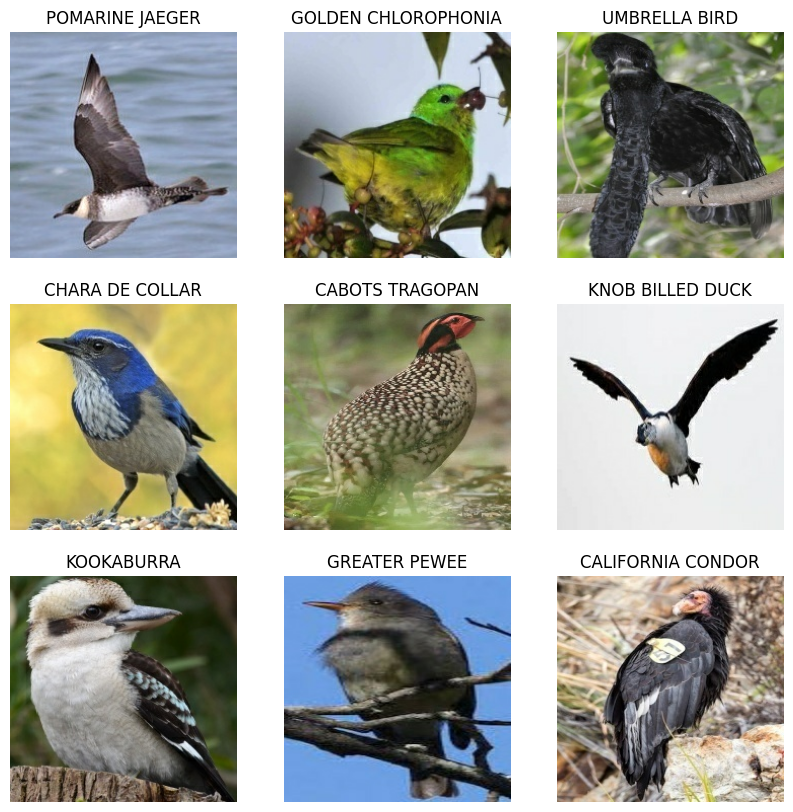

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [6]:
normalization_layer = layers.Rescaling(1./255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights=None
)

base_model.load_weights("C:/Users/armin/Downloads/Documents/Datasets/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5")
base_model.trainable = False

model = tf.keras.Sequential([
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
epochs=20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1502s 567ms/step - accuracy: 0.6227 - loss: 1.6260 - val_accuracy: 0.7954 - val_loss: 0.7578
Epoch 2/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1426s 539ms/step - accuracy: 0.8153 - loss: 0.6919 - val_accuracy: 0.8335 - val_loss: 0.6074
Epoch 3/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1347s 509ms/step - accuracy: 0.8601 - loss: 0.5102 - val_accuracy: 0.8411 - val_loss: 0.5661
Epoch 4/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1218s 460ms/step - accuracy: 0.8891 - loss: 0.3928 - val_accuracy: 0.8602 - val_loss: 0.5397
Epoch 5/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1212s 458ms/step - accuracy: 0.9101 - loss: 0.3101 - val_accuracy: 0.8610 - val_loss: 0.5507
Epoch 6/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1224s 463ms/step - accuracy: 0.9250 - loss: 0.2533 - val_accuracy: 0.8621 - val_loss: 0.5729
Epoch 7/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1220s 461ms/step - accuracy: 0.9364 - loss: 0.2099 - val_accuracy: 0.8568 - val_loss: 0.6134
Epoch 8/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1225s 463ms/s

In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights=None
)

base_model.load_weights("C:/Users/armin/Downloads/Documents/Datasets/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5")
base_model.trainable = False

model_dropout_0_2 = tf.keras.Sequential([
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
model_dropout_0_2.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
epochs=20
history = model_dropout_0_2.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1290s 486ms/step - accuracy: 0.5888 - loss: 1.7809 - val_accuracy: 0.8042 - val_loss: 0.7255
Epoch 2/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1279s 484ms/step - accuracy: 0.7741 - loss: 0.8459 - val_accuracy: 0.8385 - val_loss: 0.5943
Epoch 3/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1292s 488ms/step - accuracy: 0.8088 - loss: 0.6958 - val_accuracy: 0.8587 - val_loss: 0.5301
Epoch 4/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1299s 491ms/step - accuracy: 0.8301 - loss: 0.6089 - val_accuracy: 0.8556 - val_loss: 0.5266
Epoch 5/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1215s 459ms/step - accuracy: 0.8424 - loss: 0.5536 - val_accuracy: 0.8579 - val_loss: 0.5222
Epoch 6/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1274s 482ms/step - accuracy: 0.8512 - loss: 0.5196 - val_accuracy: 0.8724 - val_loss: 0.4875
Epoch 7/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1274s 482ms/step - accuracy: 0.8598 - loss: 0.4840 - val_accuracy: 0.8560 - val_loss: 0.5238
Epoch 8/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 1272s 481ms/s